# Imports and dependencies

In [1]:
!python -m spacy download en_core_web_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 2.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [1]:
import spacy
from spacy.matcher import Matcher
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
nlp = spacy.load("en_core_web_lg")

# Data

In [3]:
df = pd.read_csv("02_processed.csv")

In [4]:
ARTICLES_TITLES = [
    "Unidentified flying object", "1953 Iranian coup d'état", "1963 South Vietnamese coup d'état",
    "Apartheid", "Armenian genocide", "Cambodian genocide", "Anfal campaign",
    "Native Americans in the United States", "Scientology", "Soviet war crimes",
    "Chris Brown", "Angelina Jolie", "Brad Pitt", "Marilyn Manson", "Ozzy Osbourne",
    "Mikhail Gorbachev", "Saddam Hussein", "Vladimir Lenin", "Karl Marx", "Mother Teresa",
    "Elon Musk", "Andrew Tate", "Vladimir Putin", "Ronald Reagan", "Margaret Thatcher",
    "2003 invasion of Iraq", "Bashar al-Assad", "September 11 attacks", "Tibet",
    "Hezbollah", "Hamas", "Al-Qaeda", "Palestine Liberation Organization",
    "Same-sex marriage", "Saudi Arabia", "Abortion", "Gun control",
    "Healthcare reform in the United States", "Anarcho-capitalism", "Anti-Americanism",
    "Black supremacy", "National-anarchism", "Black Lives Matter", "Masculism",
    "People for the Ethical Treatment of Animals", "LGBTQ rights by country or territory",
    "Chinese intelligence activity abroad", "Cuba", "Politics of North Korea",
    "History of Israel", "Plame affair", "NATO", "CNN", "Criticism of Walmart",
    "Domestic violence", "Genocide denial", "Holodomor",
    "Russian interference in the 2016 United States elections", "Vector Marketing",
    "Salvador Allende", "Christian right", "Christian Science", "Anti-Christian sentiment",
    "Divorce", "Feminism", "Religion and LGBTQ people", "Islamophobia", "Mormonism",
    "Quran", "Sharia", "HIV/AIDS denialism", "Assisted suicide", "Euthanasia", "Eugenics",
    "Family planning", "Female genital mutilation", "Homeopathy", "Self-harm",
    "Surrogacy", "Veganism",
]

CLUSTER_TABLE = """title    topic    topic_title
Abortion    0    Controversies/miscellaneous
Anarcho-capitalism    0    Controversies/miscellaneous
Al-Qaeda    2    Middle East
Mikhail Gorbachev    1    International politics
Mormonism    0    Controversies/miscellaneous
NATO    2    Middle East
Native Americans in the United States    0    Controversies/miscellaneous
Politics of North Korea    2    Middle East
2003 invasion of Iraq    2    Middle East
Palestine Liberation Organization    2    Middle East
Family planning    0    Controversies/miscellaneous
Ronald Reagan    3    Public figures
Apartheid    0    Controversies/miscellaneous
HIV/AIDS denialism    0    Controversies/miscellaneous
Anti-Americanism    0    Controversies/miscellaneous
Plame affair    1    International politics
Sharia    2    Middle East
Saddam Hussein    2    Middle East
National-anarchism    0    Controversies/miscellaneous
Tibet    4    Genocides
Unidentified flying object    0    Controversies/miscellaneous
Mother Teresa    3    Public figures
Saudi Arabia    2    Middle East
Bashar al-Assad    1    International politics
Veganism    0    Controversies/miscellaneous
Vladimir Putin    1    International politics
Chinese intelligence activity abroad    1    International politics
1953 Iranian coup d'\u00c3\u00a9tat    2    Middle East
Quran    2    Middle East
Divorce    0    Controversies/miscellaneous
Chris Brown    3    Public figures
Gun control    1    International politics
Brad Pitt    3    Public figures
Marilyn Manson    3    Public figures
Salvador Allende    1    International politics
Anfal campaign    2    Middle East
Elon Musk    3    Public figures
People for the Ethical Treatment of Animals    0    Controversies/miscellaneous
LGBTQ rights by country or territory    0    Controversies/miscellaneous
Vector Marketing    0    Controversies/miscellaneous
CNN    2    Middle East
Christian right    0    Controversies/miscellaneous
Soviet war crimes    1    International politics
Cuba    1    International politics
September 11 attacks    2    Middle East
Black supremacy    0    Controversies/miscellaneous
Angelina Jolie    3    Public figures
Holodomor    4    Genocides
Criticism of Walmart    0    Controversies/miscellaneous
Vladimir Lenin    1    International politics
1963 South Vietnamese coup d'\u00c3\u00a9tat    4    Genocides
Scientology    0    Controversies/miscellaneous
Euthanasia    0    Controversies/miscellaneous
Eugenics    0    Controversies/miscellaneous
Ozzy Osbourne    3    Public figures
Healthcare reform in the United States    0    Controversies/miscellaneous
Same-sex marriage    0    Controversies/miscellaneous
Surrogacy    0    Controversies/miscellaneous
Domestic violence    0    Controversies/miscellaneous
Religion and LGBTQ people    0    Controversies/miscellaneous
Feminism    0    Controversies/miscellaneous
Female genital mutilation    0    Controversies/miscellaneous
Genocide denial    4    Genocides
Masculism    0    Controversies/miscellaneous
Russian interference in the 2016 United States elections    1    International politics
History of Israel    2    Middle East
Hamas    2    Middle East
Hezbollah    2    Middle East
Homeopathy    0    Controversies/miscellaneous
Cambodian genocide    4    Genocides
Andrew Tate    1    International politics
Black Lives Matter    0    Controversies/miscellaneous
Christian Science    0    Controversies/miscellaneous
Karl Marx    1    International politics
Armenian genocide    4    Genocides
Self-harm    0    Controversies/miscellaneous
Margaret Thatcher    3    Public figures
Anti-Christian sentiment    0    Controversies/miscellaneous
Islamophobia    0    Controversies/miscellaneous
Assisted suicide    0    Controversies/miscellaneous
"""

# Lexical markers


In [5]:
LEXICAL_MARKERS = {
    "epistemico_certeza": [
        "undoubtedly", "definitely", "unquestionably", "clearly",
        "certainly", "evidently", "obviously", "undeniably", "indisputably"
    ],
    "epistemico_duda": [
        "possibly", "presumably", "apparently", "reportedly", "allegedly",
        "seemingly", "ostensibly"
    ],
    "atribucion": [
        "claim", "allege", "assert", "contend", "purport", "argue",
        "suggest", "propose", "maintain", "state", "note", "observe",
        "indicate", "report", "acknowledge", "emphasize"
    ]
}

ALL_MARKERS = {lema: cat for cat, lemas in LEXICAL_MARKERS.items() for lema in lemas}

# Calculating tokens


In [6]:
par_df = df[df["title"].isin(ARTICLES_TITLES)].copy()

docs_by_title = dict(zip(
    par_df["title"],
    nlp.pipe(par_df["text"], batch_size=8, disable=["ner"])
))

par_df["n_tokens"] = par_df["title"].map(
    lambda t: len([token for token in docs_by_title[t] if not token.is_space])
)
print(par_df[["title", "n_tokens"]])

                       title  n_tokens
0                   Abortion      9901
1         Anarcho-capitalism     13378
2                   Al-Qaeda     14539
3          Mikhail Gorbachev     10092
4                  Mormonism      6226
..                       ...       ...
75                 Self-harm      7067
76         Margaret Thatcher     14245
77  Anti-Christian sentiment      2471
78              Islamophobia     12497
79          Assisted suicide     10050

[80 rows x 2 columns]


In [7]:
import re

QUOTE_CHARS = '"“”'

def get_quote_spans(doc):
    spans = []
    for sent in doc.sents:
        positions = [sent.start_char + m.start() for m in re.finditer(f"[{QUOTE_CHARS}]", sent.text)]
        spans.extend((positions[i], positions[i + 1]) for i in range(0, len(positions) - 1, 2))
    return spans

def is_in_quote_span(start_char, end_char, quote_spans):
    return any(qs <= start_char and end_char <= qe for qs, qe in quote_spans)

quote_spans_by_title = {title: get_quote_spans(docs_by_title[title]) for title in ARTICLES_TITLES}

# Negation treatment


In [8]:
POS_RESTRICTED = {"state", "report", "claim", "note"}

def is_valid_marker_token(token):
    lemma = token.lemma_.lower()
    if lemma in POS_RESTRICTED and token.pos_ != "VERB":
        return False
    sent_text = token.sent.text
    if "align=" in sent_text or "||" in sent_text:
        return False
    return True

NEG_LEMMAS = {"never"}

def _has_negator(token):
    return any(
        child.dep_ == "neg" or child.lower_ in NEG_LEMMAS
        for child in token.children
    )

def detect_markers(doc, markers, quote_spans):
    counts_affirmed = defaultdict(int)
    counts_negated = defaultdict(int)
    counts_quoted = defaultdict(int)
    hits_affirmed = defaultdict(list)
    hits_negated = defaultdict(list)
    hits_quoted = defaultdict(list)

    for token in doc:
        lemma = token.lemma_.lower()
        if lemma not in markers:
            continue
        if not is_valid_marker_token(token):
            continue

        cat = markers[lemma]
        start_char, end_char = token.idx, token.idx + len(token.text)

        if is_in_quote_span(start_char, end_char, quote_spans):
            counts_quoted[cat] += 1
            hits_quoted[cat].append(lemma)
            continue  # no refleja la voz del artículo, sino de la fuente citada

        is_negated = _has_negator(token)
        if not is_negated and token.pos_ in {"NOUN", "ADJ", "ADV"}:
            is_negated = _has_negator(token.head)

        if is_negated:
            counts_negated[cat] += 1
            hits_negated[cat].append(lemma)
        else:
            counts_affirmed[cat] += 1
            hits_affirmed[cat].append(lemma)

    return counts_affirmed, counts_negated, counts_quoted, hits_affirmed, hits_negated, hits_quoted


def build_results_df(markers, categories):
    results = []
    for _, row in par_df.iterrows():
        title = row["title"]
        doc = docs_by_title[title]
        quote_spans = quote_spans_by_title[title]
        counts_affirmed, counts_negated, counts_quoted, hits_affirmed, hits_negated, hits_quoted = detect_markers(doc, markers, quote_spans)
        entry = {"title": title}
        for cat in categories:
            entry[f"affirmed_{cat}"] = counts_affirmed.get(cat, 0)
            entry[f"negated_{cat}"] = counts_negated.get(cat, 0)
            entry[f"quoted_{cat}"] = counts_quoted.get(cat, 0)
            entry[f"total_{cat}"] = counts_affirmed.get(cat, 0)
            entry[f"hits_affirmed_{cat}"] = list(set(hits_affirmed.get(cat, [])))
            entry[f"hits_negated_{cat}"] = list(set(hits_negated.get(cat, [])))
            entry[f"hits_quoted_{cat}"] = list(set(hits_quoted.get(cat, [])))
        entry["total"] = sum(counts_affirmed.values())
        entry["total_quoted"] = sum(counts_quoted.values())
        results.append(entry)
    return pd.DataFrame(results)


results_df = build_results_df(ALL_MARKERS, LEXICAL_MARKERS.keys())

cols = ["title"]
for cat in LEXICAL_MARKERS:
    cols += [f"affirmed_{cat}", f"negated_{cat}"]
cols += ["total"]
print(results_df[cols].to_string(index=False))

                                                   title  affirmed_epistemico_certeza  negated_epistemico_certeza  affirmed_epistemico_duda  negated_epistemico_duda  affirmed_atribucion  negated_atribucion  total
                                                Abortion                            1                           0                         0                        0                   35                   0     36
                                      Anarcho-capitalism                            0                           1                         1                        0                  105                   0    106
                                                Al-Qaeda                            0                           0                         9                        0                   52                   1     61
                                       Mikhail Gorbachev                            1                           0                         0         

## Normalized frequencies (1000 tokens)


In [9]:
for _, row in results_df.iterrows():
    n = par_df.loc[par_df["title"] == row["title"], "n_tokens"].values[0]
    print(f"\n{row['title']} ({n} tokens)")
    for cat in LEXICAL_MARKERS:
        raw = row[f"affirmed_{cat}"]
        norm = round(raw / n * 1000, 3)
        print(f"  {cat}: {raw} raw → {norm} por 1000 tokens")
    print(f"  TOTAL: {row['total']} raw → {round(row['total']/n*1000, 3)} por 1000 tokens")


Abortion (9901 tokens)
  epistemico_certeza: 1 raw → 0.101 por 1000 tokens
  epistemico_duda: 0 raw → 0.0 por 1000 tokens
  atribucion: 35 raw → 3.535 por 1000 tokens
  TOTAL: 36 raw → 3.636 por 1000 tokens

Anarcho-capitalism (13378 tokens)
  epistemico_certeza: 0 raw → 0.0 por 1000 tokens
  epistemico_duda: 1 raw → 0.075 por 1000 tokens
  atribucion: 105 raw → 7.849 por 1000 tokens
  TOTAL: 106 raw → 7.923 por 1000 tokens

Al-Qaeda (14539 tokens)
  epistemico_certeza: 0 raw → 0.0 por 1000 tokens
  epistemico_duda: 9 raw → 0.619 por 1000 tokens
  atribucion: 52 raw → 3.577 por 1000 tokens
  TOTAL: 61 raw → 4.196 por 1000 tokens

Mikhail Gorbachev (10092 tokens)
  epistemico_certeza: 1 raw → 0.099 por 1000 tokens
  epistemico_duda: 0 raw → 0.0 por 1000 tokens
  atribucion: 25 raw → 2.477 por 1000 tokens
  TOTAL: 26 raw → 2.576 por 1000 tokens

Mormonism (6226 tokens)
  epistemico_certeza: 0 raw → 0.0 por 1000 tokens
  epistemico_duda: 1 raw → 0.161 por 1000 tokens
  atribucion: 21 raw

# Manual check


In [10]:
atribucion_markers = set(LEXICAL_MARKERS["atribucion"])

for title in ARTICLES_TITLES:
    doc = docs_by_title[title]
    hits = []
    for sent in doc.sents:
        for token in sent:
            if token.lemma_.lower() in atribucion_markers and is_valid_marker_token(token):
                hits.append({
                    "posicion": token.i,
                    "token": token.text,
                    "lemma": token.lemma_.lower(),
                    "oracion": sent.text.strip()
                })
    print(f"\n{'='*60}\n{title}\n{'='*60}")
    if not hits:
        print("(sin marcadores de atribución)")
        continue
    hits_df = pd.DataFrame(hits)
    print(hits_df.to_string(index=False))


Unidentified flying object
 posicion        token       lemma                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  oracion
       46     reported      report                                                                                                                                                                                                                                                                                                                                                                             T

# Patterns with Matcher


In [11]:
matcher = Matcher(nlp.vocab)

matcher.add("MODAL_VERB", [
    [{"LOWER": {"IN": ["may", "might", "could", "would"]}}, {"POS": "VERB"}],
    [{"LOWER": {"IN": ["may", "might", "could", "would"]}}, {"POS": {"IN": ["ADV", "PART"]}}, {"POS": "VERB"}]
])
matcher.add("EPISTEMIC_TO", [
    [{"LOWER": {"IN": ["appear", "seem", "tend"]}}, {"LOWER": "to"}, {"POS": "VERB"}]
])
matcher.add("EPISTEMIC_ADJ", [
    [{"LOWER": "it"}, {"LOWER": "is"},
     {"LOWER": {"IN": ["possible", "likely", "unlikely", "probable"]}},
     {"LOWER": "that"}]
])
matcher.add("ACCORDING_TO", [
    [{"LOWER": "according"}, {"LOWER": "to"}]
])
matcher.add("PASSIVE_EPISTEMIC", [
    [{"LOWER": "it"}, {"LOWER": "has"}, {"LOWER": "been"},
     {"LOWER": {"IN": ["suggested", "argued", "claimed", "reported",
                       "noted", "proposed", "maintained", "asserted"]}},
     {"LOWER": "that"}]
])
matcher.add("PASSIVE_HEDGE", [
    [{"LOWER": {"IN": ["is", "are"]}},
     {"LOWER": {"IN": ["considered", "believed", "thought", "known", "said"]}},
     {"LOWER": "to"}]
])
matcher.add("SCOPE_ADV", [
    [{"LOWER": {"IN": ["generally", "widely", "largely", "commonly",
                       "typically", "traditionally", "historically"]}},
     {"POS": "VERB"}]
])

matcher.add("EPISTEMIC_LIKELY_TO", [
    [{"LOWER": {"IN": ["is", "are", "was", "were"]}},
     {"LOWER": {"IN": ["likely", "unlikely", "possible", "probable"]}},
     {"LOWER": "to"}]
])

matcher.add("BOOSTER_ADV", [
    [{"LOWER": {"IN": ["undoubtedly", "definitely", "certainly", "clearly",
                       "obviously", "evidently", "undeniably", "indisputably"]}},
     {"POS": "VERB"}]
])
matcher.add("BOOSTER_ADJ", [
    [{"LOWER": "it"}, {"LOWER": "is"},
     {"LOWER": {"IN": ["clear", "obvious", "certain", "evident", "undeniable", "indisputable"]}},
     {"LOWER": "that"}]
])
matcher.add("NO_DOUBT", [
    [{"LOWER": "there"}, {"LOWER": {"IN": ["is", "was"]}}, {"LOWER": "no"},
     {"LOWER": {"IN": ["doubt", "question"]}}, {"LOWER": "that"}]
])
matcher.add("IN_FACT", [
    [{"LOWER": "in"}, {"LOWER": "fact"}]
])

HEDGE_PATTERNS = ["MODAL_VERB", "EPISTEMIC_TO", "EPISTEMIC_ADJ", "EPISTEMIC_LIKELY_TO",
                  "ACCORDING_TO", "PASSIVE_EPISTEMIC", "PASSIVE_HEDGE", "SCOPE_ADV"]
BOOST_PATTERNS = ["BOOSTER_ADV", "BOOSTER_ADJ", "NO_DOUBT", "IN_FACT"]
ALL_PATTERNS = HEDGE_PATTERNS + BOOST_PATTERNS


def detect_epistemic_patterns(doc, quote_spans):
    matches = matcher(doc)
    counts = {k: 0 for k in ALL_PATTERNS}
    counts_quoted = {k: 0 for k in ALL_PATTERNS}
    hits = {k: [] for k in ALL_PATTERNS}
    hits_quoted = {k: [] for k in ALL_PATTERNS}
    for match_id, start, end in matches:
        label = nlp.vocab.strings[match_id]
        span = doc[start:end]
        if is_in_quote_span(span.start_char, span.end_char, quote_spans):
            counts_quoted[label] += 1
            hits_quoted[label].append(span.text)
            continue
        counts[label] += 1
        hits[label].append(span.text)
    return counts, counts_quoted, hits, hits_quoted


epistemic_results = []
for _, row in par_df.iterrows():
    title = row["title"]
    doc = docs_by_title[title]
    quote_spans = quote_spans_by_title[title]
    counts, counts_quoted, hits, hits_quoted = detect_epistemic_patterns(doc, quote_spans)
    n = par_df.loc[par_df["title"] == title, "n_tokens"].values[0]

    entry = {"title": title}
    for pat in ALL_PATTERNS:
        entry[f"count_{pat}"] = counts[pat]
        entry[f"norm_{pat}"] = round(counts[pat] / n * 1000, 3)
        entry[f"hits_{pat}"] = hits[pat]
        entry[f"quoted_{pat}"] = counts_quoted[pat]
        entry[f"hits_quoted_{pat}"] = hits_quoted[pat]

    total_hedging = sum(counts[p] for p in HEDGE_PATTERNS)
    total_boosting = sum(counts[p] for p in BOOST_PATTERNS)
    entry["total_hedging"] = total_hedging
    entry["norm_hedging"] = round(total_hedging / n * 1000, 3)
    entry["total_boosting"] = total_boosting
    entry["norm_boosting"] = round(total_boosting / n * 1000, 3)
    entry["hedge_boost_ratio"] = round(total_hedging / total_boosting, 3) if total_boosting else float("inf")

    entry["total_quoted_hedging"] = sum(counts_quoted[p] for p in HEDGE_PATTERNS)
    entry["total_quoted_boosting"] = sum(counts_quoted[p] for p in BOOST_PATTERNS)

    epistemic_results.append(entry)

epistemic_df = pd.DataFrame(epistemic_results)
print(epistemic_df[[c for c in epistemic_df.columns if c.startswith("count_") or c.startswith("norm_")
                     or c in ["title", "total_hedging", "total_boosting", "hedge_boost_ratio"]]].to_string(index=False))

                                                   title  count_MODAL_VERB  norm_MODAL_VERB  count_EPISTEMIC_TO  norm_EPISTEMIC_TO  count_EPISTEMIC_ADJ  norm_EPISTEMIC_ADJ  count_EPISTEMIC_LIKELY_TO  norm_EPISTEMIC_LIKELY_TO  count_ACCORDING_TO  norm_ACCORDING_TO  count_PASSIVE_EPISTEMIC  norm_PASSIVE_EPISTEMIC  count_PASSIVE_HEDGE  norm_PASSIVE_HEDGE  count_SCOPE_ADV  norm_SCOPE_ADV  count_BOOSTER_ADV  norm_BOOSTER_ADV  count_BOOSTER_ADJ  norm_BOOSTER_ADJ  count_NO_DOUBT  norm_NO_DOUBT  count_IN_FACT  norm_IN_FACT  total_hedging  norm_hedging  total_boosting  norm_boosting  hedge_boost_ratio
                                                Abortion                24            2.424                   2              0.202                    0               0.000                          1                     0.101                   7              0.707                        0                   0.000                    5               0.505               10           1.010              

In [12]:
total_quoted = results_df["total_quoted"].sum()
total_all = results_df["total"].sum() + total_quoted
print(f"{total_quoted} de {total_all} hits totales cayeron dentro de comillas ({total_quoted/total_all:.1%})")

# muestra para confirmar que el heurístico no está sobre/infra-detectando
muestra = []
for cat in LEXICAL_MARKERS:
    for title in ARTICLES_TITLES[:5]:
        doc = docs_by_title[title]

143 de 4027 hits totales cayeron dentro de comillas (3.6%)


In [13]:
quote_counts = {
    title: len(re.findall(f"[{QUOTE_CHARS}]", docs_by_title[title].text))
    for title in ARTICLES_TITLES
}
odd_parity = {t: c for t, c in quote_counts.items() if c % 2 != 0}
print(f"{len(odd_parity)} de {len(ARTICLES_TITLES)} artículos con número impar de comillas")
for t, c in sorted(odd_parity.items(), key=lambda x: -x[1])[:10]:
    print(f"  {t}: {c} comillas")

28 de 80 artículos con número impar de comillas
  Chris Brown: 663 comillas
  Hezbollah: 445 comillas
  Scientology: 405 comillas
  People for the Ethical Treatment of Animals: 383 comillas
  Vladimir Putin: 377 comillas
  2003 invasion of Iraq: 375 comillas
  Unidentified flying object: 355 comillas
  Anarcho-capitalism: 355 comillas
  Criticism of Walmart: 321 comillas
  1953 Iranian coup d'état: 281 comillas


In [14]:
quoted_pct = (
    results_df.set_index("title")["total_quoted"] /
    (results_df.set_index("title")["total"] + results_df.set_index("title")["total_quoted"])
).fillna(0).sort_values(ascending=False)
print(quoted_pct.head(10))

title
Anti-Christian sentiment                                    0.166667
1953 Iranian coup d'état                                    0.121951
Assisted suicide                                            0.117647
People for the Ethical Treatment of Animals                 0.102041
Plame affair                                                0.094595
National-anarchism                                          0.086207
Black Lives Matter                                          0.084746
Masculism                                                   0.076923
Holodomor                                                   0.073171
Russian interference in the 2016 United States elections    0.062112
dtype: float64


In [15]:
def count_odd_sentences(doc):
    return sum(
        1 for sent in doc.sents
        if len(re.findall(f"[{QUOTE_CHARS}]", sent.text)) % 2 != 0
    )

odd_sentences = {title: count_odd_sentences(docs_by_title[title]) for title in ARTICLES_TITLES}
print(f"Total de oraciones con comilla huérfana en todo el corpus: {sum(odd_sentences.values())}")

Total de oraciones con comilla huérfana en todo el corpus: 2146


In [16]:
sample_check = []
for title in ARTICLES_TITLES[:8]:
    doc = docs_by_title[title]
    quote_spans = quote_spans_by_title[title]
    for token in doc:
        lemma = token.lemma_.lower()
        if lemma not in ALL_MARKERS or not is_valid_marker_token(token):
            continue
        start_char, end_char = token.idx, token.idx + len(token.text)
        if is_in_quote_span(start_char, end_char, quote_spans):
            sample_check.append({
                "title": title, "token": token.text, "lemma": lemma,
                "oracion": token.sent.text.strip()[:200]
            })

sample_df = pd.DataFrame(sample_check)
print(sample_df.sample(min(15, len(sample_df)), random_state=0).to_string(index=False))

                                title        token       lemma                                                                                                                                                                                                    oracion
           Unidentified flying object    certainly   certainly   Such "mudslinging over convictions is certainly familiar to historians of religion, a domain of human existence marked by deep divisions over interpretations of belief", and science too has found itse
             1953 Iranian coup d'état        claim       claim   It has even been suggested that Roosevelt's activities between 15 and 19 August were primarily intended to organize "stay-behind networks as part of the planned CIA evacuation of the country", althoug
             1953 Iranian coup d'état      arguing       argue "\n\nIn 2004, Gasiorowski edited a book on the coup arguing that "the climate of intense cold war rivalry between the superpowers, together

# Consolidation

In [ ]:
top_hedging_antes = epistemic_df.nlargest(10, "norm_hedging")["title"].tolist()

epistemic_df = epistemic_df.merge(
    results_df[["title", "total_epistemico_certeza", "total_epistemico_duda", "total_atribucion"]],
    on="title", how="left"
)

n_tokens_lookup = par_df.set_index("title")["n_tokens"]

epistemic_df["total_hedging_sintactico"] = epistemic_df["total_hedging"]
epistemic_df["total_boosting_sintactico"] = epistemic_df["total_boosting"]

hedge_cols_sin_solape = [f"count_{p}" for p in HEDGE_PATTERNS if p != "PASSIVE_EPISTEMIC"]
boost_cols_sin_solape = [f"count_{p}" for p in BOOST_PATTERNS if p != "BOOSTER_ADV"]

epistemic_df["total_hedging"] = (
    epistemic_df[hedge_cols_sin_solape].sum(axis=1)
    + epistemic_df["total_epistemico_duda"]
    + epistemic_df["total_atribucion"]
)
epistemic_df["total_boosting"] = (
    epistemic_df[boost_cols_sin_solape].sum(axis=1)
    + epistemic_df["total_epistemico_certeza"]
)

n_tokens = epistemic_df["title"].map(n_tokens_lookup)
epistemic_df["norm_hedging"] = (epistemic_df["total_hedging"] / n_tokens * 1000).round(3)
epistemic_df["norm_boosting"] = (epistemic_df["total_boosting"] / n_tokens * 1000).round(3)
epistemic_df["hedge_boost_ratio"] = epistemic_df.apply(
    lambda r: round(r["total_hedging"] / r["total_boosting"], 3) if r["total_boosting"] else float("inf"),
    axis=1
)

## Visualization

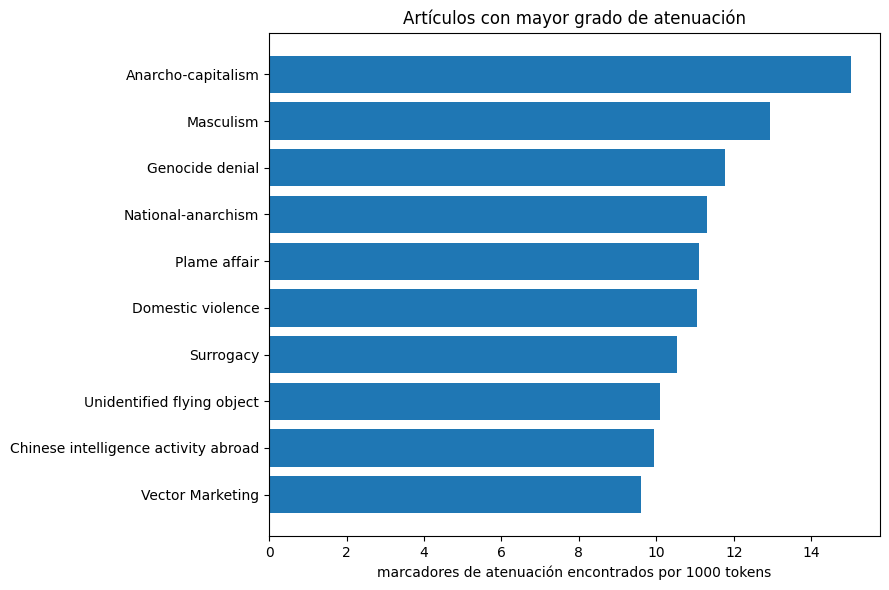

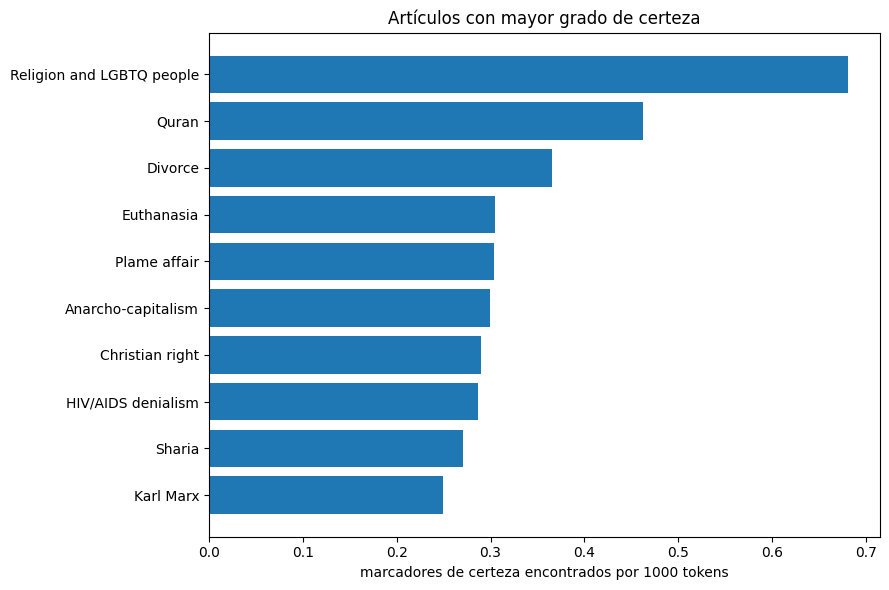

In [18]:
top_hedging = epistemic_df.nlargest(10, "norm_hedging").sort_values("norm_hedging")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_hedging["title"], top_hedging["norm_hedging"])
ax.set_xlabel("marcadores de atenuación encontrados por 1000 tokens")
ax.set_title("Artículos con mayor grado de atenuación")
plt.tight_layout()
plt.show()

top_boosting = epistemic_df.nlargest(10, "norm_boosting").sort_values("norm_boosting")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_boosting["title"], top_boosting["norm_boosting"])
ax.set_xlabel("marcadores de certeza encontrados por 1000 tokens")
ax.set_title("Artículos con mayor grado de certeza")
plt.tight_layout()
plt.show()

In [19]:
from io import StringIO

cluster_df = pd.read_csv(StringIO(CLUSTER_TABLE), sep=r"\s\s+", engine="python")

def fix_mojibake(s):
    try:
        return s.encode("latin-1").decode("utf-8")
    except (UnicodeDecodeError, UnicodeEncodeError):
        return s

cluster_df["title"] = cluster_df["title"].apply(fix_mojibake)

In [20]:
cluster_agg = epistemic_df.merge(cluster_df, on="title", how="left")

missing = cluster_agg[cluster_agg["topic_title"].isna()]
if not missing.empty:
    print("Sin clúster asignado:", missing["title"].tolist())

cluster_agg = cluster_agg.merge(par_df[["title", "n_tokens"]], on="title")

cluster_grouped = cluster_agg.groupby("topic_title").agg(
    total_hedging=("total_hedging", "sum"),
    total_boosting=("total_boosting", "sum"),
    total_tokens=("n_tokens", "sum"),
    n_articulos=("title", "count")
).reset_index()

cluster_grouped["norm_hedging"] = round(cluster_grouped["total_hedging"] / cluster_grouped["total_tokens"] * 1000, 3)
cluster_grouped["norm_boosting"] = round(cluster_grouped["total_boosting"] / cluster_grouped["total_tokens"] * 1000, 3)
cluster_grouped["hedge_boost_ratio"] = round(cluster_grouped["total_hedging"] / cluster_grouped["total_boosting"], 3)

cluster_grouped = cluster_grouped.sort_values("norm_hedging", ascending=False)
print(cluster_grouped.to_string(index=False))

                topic_title  total_hedging  total_boosting  total_tokens  n_articulos  norm_hedging  norm_boosting  hedge_boost_ratio
Controversies/miscellaneous           2832              42        369666           36         7.661          0.114             67.429
     International politics           1359              22        197470           13         6.882          0.111             61.773
                  Genocides            413               4         61616            6         6.703          0.065            103.250
                Middle East           1440              27        233498           16         6.167          0.116             53.333
             Public figures            521               4        109466            9         4.759          0.037            130.250


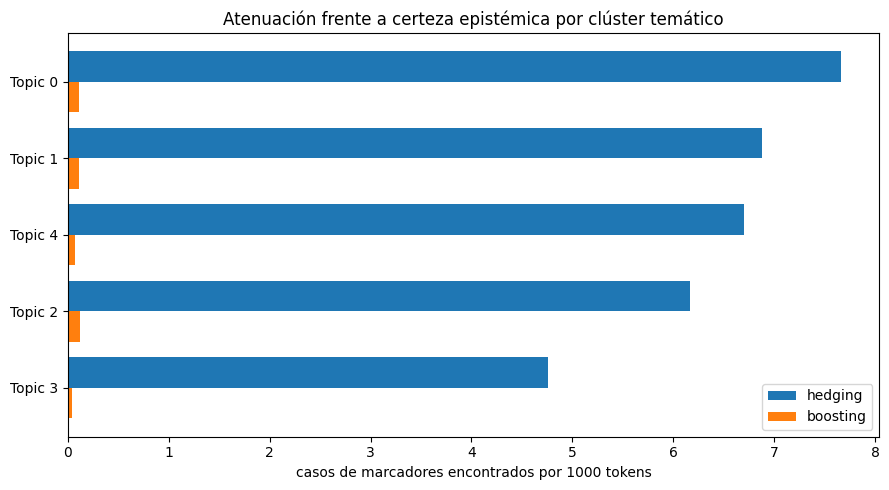

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(cluster_grouped))
ax.barh(y - 0.2, cluster_grouped["norm_hedging"], height=0.4, label="hedging")
ax.barh(y + 0.2, cluster_grouped["norm_boosting"], height=0.4, label="boosting")
ax.set_yticks(y)

topic_id_by_title = cluster_df.drop_duplicates("topic_title").set_index("topic_title")["topic"]
labels = cluster_grouped["topic_title"].map(topic_id_by_title)
ax.set_yticklabels([f"Topic {t}" for t in labels])

ax.set_xlabel("casos de marcadores encontrados por 1000 tokens")
ax.set_title("Atenuación frente a certeza epistémica por clúster temático")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

## Saving data

In [22]:
results_df.to_csv("07_results_lexical_markers.csv", index=False)
epistemic_df.to_csv("07_results_epistemic_patterns.csv", index=False)
cluster_grouped.to_csv("07_results_per_cluster.csv", index=False)